# Lagos Rent Data Analysis

I created this notebook to explore a small sample of rental listings from different parts of Lagos.

The aim is to compare rent prices, look at differences between property types and practise presenting simple findings with Pandas and Matplotlib.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

data_file = (
    project_folder
    / "data"
    / "cleaned"
    / "lagos_rent_cleaned.csv"
)

rent_data = pd.read_csv(data_file)

print(f"Number of listings: {len(rent_data)}")
rent_data.head()

Number of listings: 10


,location,property_type,bedrooms,bathrooms,annual_rent
0,Yaba,Flat,2,2,2500000
1,Lekki,Apartment,3,3,5500000
2,Ikeja,Flat,2,2,3500000
3,Surulere,Mini Flat,1,1,1200000
4,Ajah,Apartment,3,3,3200000


In [25]:
rent_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   location       10 non-null     str  
 1   property_type  10 non-null     str  
 2   bedrooms       10 non-null     int64
 3   bathrooms      10 non-null     int64
 4   annual_rent    10 non-null     int64
dtypes: int64(3), str(2)
memory usage: 532.0 bytes


In [26]:
rent_data.describe()

,bedrooms,bathrooms,annual_rent
count,10.000000,10.000000,1.000000e+01
mean,2.300000,2.300000,4.360000e+06
std,0.948683,0.948683,3.543131e+06
min,1.000000,1.000000,9.000000e+05
25%,2.000000,2.000000,2.575000e+06
50%,2.000000,2.000000,3.100000e+06
75%,3.000000,3.000000,5.000000e+06
max,4.000000,4.000000,1.200000e+07


In [27]:
average_rent = rent_data["annual_rent"].mean()
median_rent = rent_data["annual_rent"].median()

print(f"Average annual rent: ₦{average_rent:,.0f}")
print(f"Median annual rent: ₦{median_rent:,.0f}")

Average annual rent: ₦4,360,000
Median annual rent: ₦3,100,000


In [28]:
average_by_property = (
    rent_data.groupby("property_type")["annual_rent"]
    .mean()
    .sort_values()
)

average_by_property

property_type
Mini Flat    1050000.0
Flat         2950000.0
Apartment    7425000.0
Name: annual_rent, dtype: float64

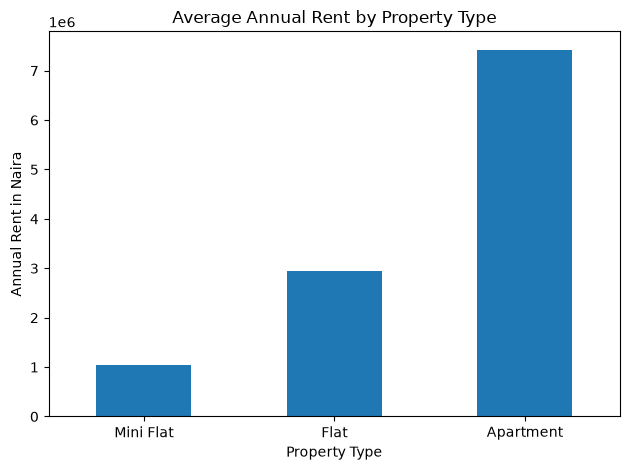

In [29]:
average_by_property.plot(
    kind="bar",
    title="Average Annual Rent by Property Type",
)

plt.xlabel("Property Type")
plt.ylabel("Annual Rent in Naira")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Early Findings

From this small dataset, apartments have the highest average annual rent, while mini flats have the lowest.

Ikoyi has the most expensive listing in the sample, and Agege has the cheapest. The difference between the average and median rent also suggests that a few expensive properties are pushing the average upwards.

This is only a small practice dataset, so the results should not be treated as a full representation of the Lagos rental market.